Hosting Capacity of Generation

In [16]:
#import libraries for checking hosting capacity

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandapower.create import create_sgen
import math

from pandapower import from_pickle
from pandapower.run import runpp
from pandapower.create import (
    create_gen,
    create_load
)

In [2]:
#load ieee 9-bus systems

def load_network():
    return from_pickle("ieee9bus.p")

In [3]:
#define violations

def violations(net):
    runpp(net)
    if net.res_line.loading_percent.max() > 100:
        return (True, "Line Overloading")
    elif net.res_trafo.loading_percent.max() > 100:
        return (True, "Transformer Overloading")
    elif net.res_bus.vm_pu.max() > 1.05:
        return (True, "Bus overvoltage")
    elif net.res_bus.vm_pu.min() < 0.90:
        return (True, "Bus undervoltage")
    elif net.res_ext_grid.p_mw.min() < 0:
        return (True, "Zero export")
    elif (net.res_ext_grid.at[0,"p_mw"] > net.ext_grid.at[0,"max_p_mw"]) or (net.res_ext_grid.at[1,"p_mw"] > net.ext_grid.at[1,"max_p_mw"]) or (net.res_ext_grid.at[2,"p_mw"] > net.ext_grid.at[2,"max_p_mw"]):
        return (True, "Maximum P limit")
    elif (net.res_ext_grid.at[0,"q_mvar"] < net.ext_grid.at[0,"min_q_mvar"]) or (net.res_ext_grid.at[1,"q_mvar"] < net.ext_grid.at[1,"min_q_mvar"]) or (net.res_ext_grid.at[2,"q_mvar"] < net.ext_grid.at[2,"min_q_mvar"]):
        return (True, "Underexcitation limited")
    elif (net.res_ext_grid.at[0,"q_mvar"] > net.ext_grid.at[0,"max_q_mvar"]) or (net.res_ext_grid.at[1,"q_mvar"] > net.ext_grid.at[1,"max_q_mvar"]) or (net.res_ext_grid.at[2,"q_mvar"] > net.ext_grid.at[2,"max_q_mvar"]):
        return (True, "Overexcitation limited")
    else:
        return (False, None)

In [4]:
def choose_bus(net,i):
    return net.load.bus.values[i]

In [5]:
#define generation size
def get_plant_size(pf):
    plant_mw = 0.5*abs(pf)
    if pf > 0:
        plant_mvar = 0.5*math.sqrt(1-pf**2)
    else:
        plant_mvar = -0.5*math.sqrt(1-pf**2)
    
    return (plant_mw, plant_mvar)

In [6]:
#iteration to find hosting capacity

def hc(pf,type):
    iterations = 6
    results = pd.DataFrame(columns=["installed_mw", "installed_mvar", "violation"])

    if (pf < -1) or (pf > 1):
        return print("power factor incorrect")

    if type == "gen":
        for i in range(iterations):
            net = load_network()
            installed_mw=0
            installed_mvar=0
            gen_new = create_gen(net, bus=choose_bus(net,i), p_mw=0, q_mvar=0)
            while 1:
                violated, violation_type = violations(net)
                if violated:
                    results.loc[i] = [installed_mw, installed_mvar, violation_type]
                    print("Hosting capacity of bus " + str(choose_bus(net,i)) + ": Installed MW = " + str(installed_mw) + "MW, Installed MVAR = " + str(installed_mvar) + "MVAr, violations = " + violation_type)
                    break
                else:
                    plant_mw, plant_mvar = get_plant_size(pf)
                    installed_mw += plant_mw
                    installed_mvar += plant_mvar
                    net.gen.at[gen_new,"p_mw"]=installed_mw
                    net.gen.at[gen_new,"q_mvar"]=installed_mvar
        return results
    elif type == "load":
        for i in range(iterations):
            net = load_network()
            installed_mw=0
            installed_mvar=0
            load_new = create_load(net, bus=choose_bus(net,i), p_mw=0, q_mvar=0)
            while 1:
                violated, violation_type = violations(net)
                if violated:
                    results.loc[i] = [installed_mw, installed_mvar, violation_type]
                    print("Hosting capacity of bus " + str(choose_bus(net,i)) + ": Installed MW = " + str(installed_mw) + "MW, Installed MVAR = " + str(installed_mvar) + "MVAr, violations = " + violation_type)
                    break
                else:
                    plant_mw, plant_mvar = get_plant_size(pf)
                    installed_mw += plant_mw
                    installed_mvar += plant_mvar
                    net.load.at[load_new,"p_mw"]=installed_mw
                    net.load.at[load_new,"q_mvar"]=installed_mvar
        return results
    else:
        return print("Type incorrect")

In [7]:
#plot results

def hc_results(results):
    %matplotlib inline
    plt.rc('xtick', labelsize=9)    # fontsize of the tick labels
    plt.rc('ytick', labelsize=9)    # fontsize of the tick labels
    plt.rc('legend', fontsize=9)    # fontsize of the tick labels
    plt.rc('axes', labelsize=10)    # fontsize of the tick labels
    plt.rcParams['font.size'] = 10

    sns.set_style("whitegrid", {'axes.grid' : False})
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10,5))
    ax = axes[0]
    sns.boxplot(results.installed_mw, width=.1, ax=ax, orient="v")
    ax.set_ylabel("Installed Active Power [MW]")

    ax = axes[1]
    sns.boxplot(results.installed_mvar, width=.1, ax=ax, orient="v")
    ax.set_ylabel("Installed Reactive Power [MVAr]")

    ax = axes[2]
    ax.axis("equal")
    results.violation.value_counts().plot(kind="pie", ax=ax,  autopct=lambda x:"%.0f %%"%x)
    ax.set_ylabel("")
    ax.set_xlabel("")
    sns.despine()
    plt.tight_layout()

Hosting Capacity of Generation - Unity Power Factor

In [8]:
gen_pf1 = hc(1,"gen")

Hosting capacity of bus 4: Installed MW = 92.0MW, Installed MVAR = 0.0MVAr, violations = Zero export
Hosting capacity of bus 5: Installed MW = 128.0MW, Installed MVAR = 0.0MVAr, violations = Zero export
Hosting capacity of bus 6: Installed MW = 131.0MW, Installed MVAR = 0.0MVAr, violations = Zero export
Hosting capacity of bus 7: Installed MW = 231.5MW, Installed MVAR = 0.0MVAr, violations = Zero export
Hosting capacity of bus 8: Installed MW = 226.5MW, Installed MVAR = 0.0MVAr, violations = Zero export
Hosting capacity of bus 9: Installed MW = 123.0MW, Installed MVAR = 0.0MVAr, violations = Zero export


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


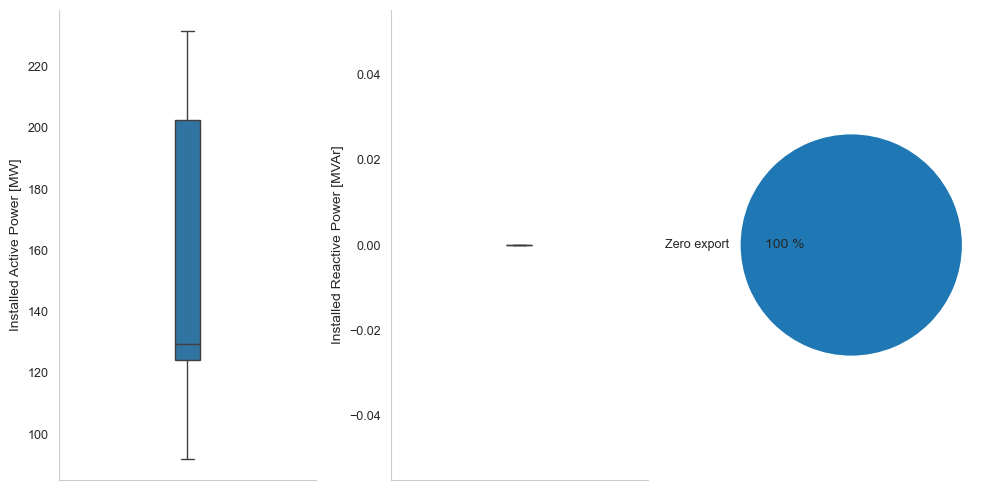

In [9]:
hc_results(gen_pf1)

Hosting Capacity of Generation - PF leading

In [10]:
gen_pflead = hc(0.85,"gen")

Hosting capacity of bus 4: Installed MW = 92.22499999999964MW, Installed MVAR = 57.15592160922611MVAr, violations = Zero export
Hosting capacity of bus 5: Installed MW = 127.9249999999994MW, Installed MVAR = 79.28079449021727MVAr, violations = Zero export
Hosting capacity of bus 6: Installed MW = 130.89999999999947MW, Installed MVAR = 81.12453389696655MVAr, violations = Zero export
Hosting capacity of bus 7: Installed MW = 231.62500000000216MW, Installed MVAR = 143.5482823826207MVAr, violations = Zero export
Hosting capacity of bus 8: Installed MW = 226.52500000000202MW, Installed MVAR = 140.3875862567648MVAr, violations = Zero export
Hosting capacity of bus 9: Installed MW = 122.82499999999943MW, Installed MVAR = 76.12009836436137MVAr, violations = Zero export


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


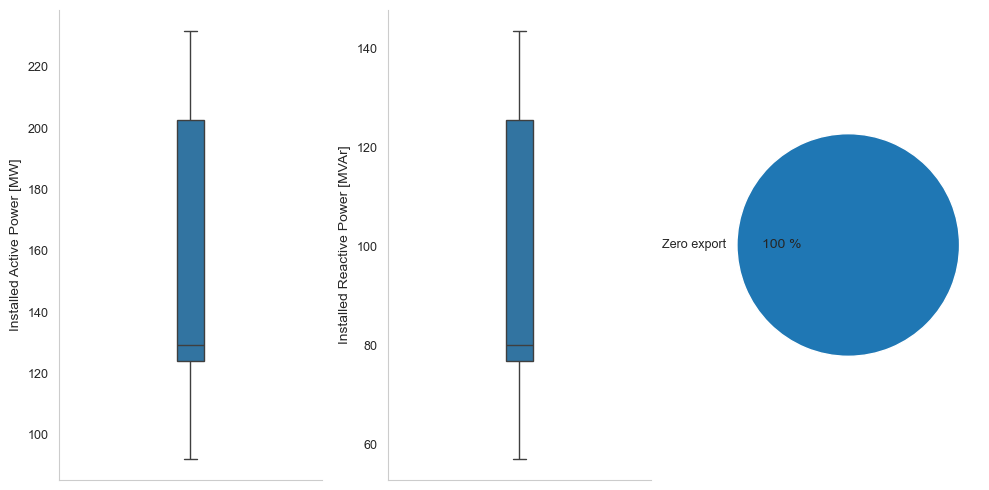

In [11]:
hc_results(gen_pflead)

Hosing Capacity of Generation - PF lagging

In [12]:
gen_pflag = hc(-0.85,"gen")

Hosting capacity of bus 4: Installed MW = 92.22499999999964MW, Installed MVAR = -57.15592160922611MVAr, violations = Zero export
Hosting capacity of bus 5: Installed MW = 127.9249999999994MW, Installed MVAR = -79.28079449021727MVAr, violations = Zero export
Hosting capacity of bus 6: Installed MW = 130.89999999999947MW, Installed MVAR = -81.12453389696655MVAr, violations = Zero export
Hosting capacity of bus 7: Installed MW = 231.62500000000216MW, Installed MVAR = -143.5482823826207MVAr, violations = Zero export
Hosting capacity of bus 8: Installed MW = 226.52500000000202MW, Installed MVAR = -140.3875862567648MVAr, violations = Zero export
Hosting capacity of bus 9: Installed MW = 122.82499999999943MW, Installed MVAR = -76.12009836436137MVAr, violations = Zero export


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


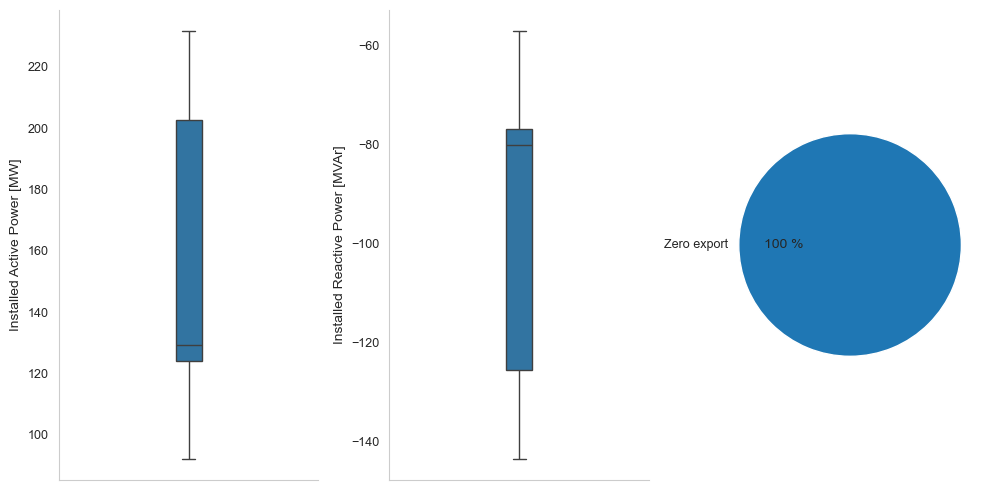

In [13]:
hc_results(gen_pflag)

Hosting Capacity of Consumption - Unity Power Factor

In [17]:
load_pf1 = hc(1,"load")

Hosting capacity of bus 4: Installed MW = 18.5MW, Installed MVAR = 0.0MVAr, violations = Maximum P limit
Hosting capacity of bus 5: Installed MW = 7.5MW, Installed MVAR = 0.0MVAr, violations = Maximum P limit
Hosting capacity of bus 6: Installed MW = 16.5MW, Installed MVAR = 0.0MVAr, violations = Maximum P limit
Hosting capacity of bus 7: Installed MW = 4.0MW, Installed MVAR = 0.0MVAr, violations = Maximum P limit
Hosting capacity of bus 8: Installed MW = 5.5MW, Installed MVAR = 0.0MVAr, violations = Maximum P limit
Hosting capacity of bus 9: Installed MW = 15.0MW, Installed MVAR = 0.0MVAr, violations = Maximum P limit


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


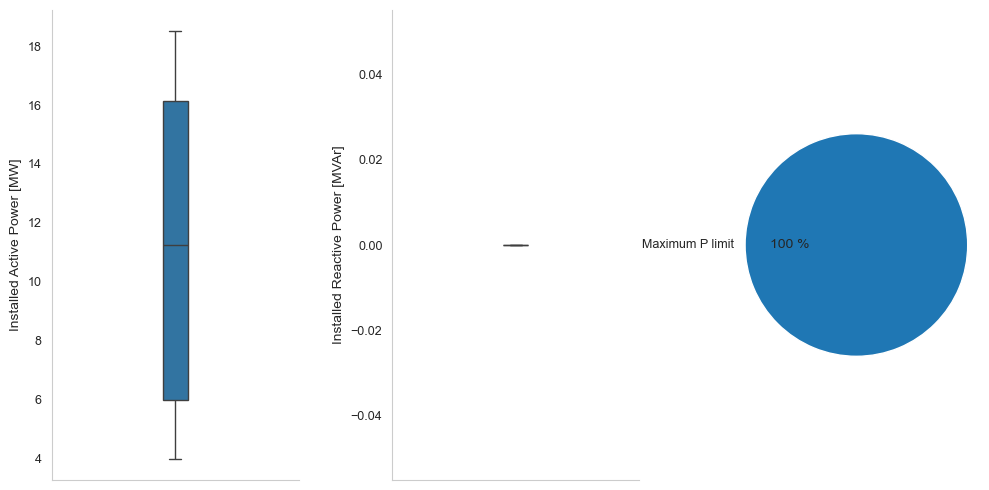

In [18]:
hc_results(load_pf1)

Hosting Capacity of Consumption - PF leading

In [19]:
load_pflead = hc(-0.8,"load")

Hosting capacity of bus 4: Installed MW = 18.799999999999997MW, Installed MVAR = -14.10000000000001MVAr, violations = Maximum P limit
Hosting capacity of bus 5: Installed MW = 7.200000000000002MW, Installed MVAR = -5.399999999999998MVAr, violations = Maximum P limit
Hosting capacity of bus 6: Installed MW = 16.800000000000004MW, Installed MVAR = -12.600000000000007MVAr, violations = Maximum P limit
Hosting capacity of bus 7: Installed MW = 3.5999999999999996MW, Installed MVAR = -2.699999999999999MVAr, violations = Maximum P limit
Hosting capacity of bus 8: Installed MW = 5.2MW, Installed MVAR = -3.899999999999998MVAr, violations = Maximum P limit
Hosting capacity of bus 9: Installed MW = 15.200000000000008MW, Installed MVAR = -11.400000000000004MVAr, violations = Maximum P limit


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


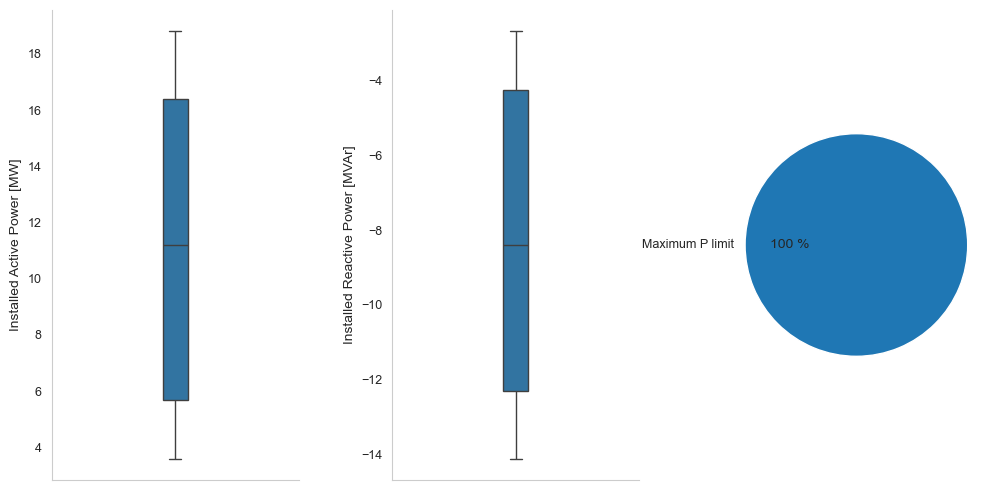

In [20]:
hc_results(load_pflead)

Hosting Capacity of Consumption - PF lagging

In [21]:
load_pflag = hc(0.8,"load")

Hosting capacity of bus 4: Installed MW = 18.0MW, Installed MVAR = 13.500000000000009MVAr, violations = Maximum P limit
Hosting capacity of bus 5: Installed MW = 8.000000000000002MW, Installed MVAR = 5.999999999999997MVAr, violations = Maximum P limit
Hosting capacity of bus 6: Installed MW = 16.000000000000007MW, Installed MVAR = 12.000000000000005MVAr, violations = Maximum P limit
Hosting capacity of bus 7: Installed MW = 3.9999999999999996MW, Installed MVAR = 2.9999999999999987MVAr, violations = Maximum P limit
Hosting capacity of bus 8: Installed MW = 5.6000000000000005MW, Installed MVAR = 4.199999999999998MVAr, violations = Maximum P limit
Hosting capacity of bus 9: Installed MW = 14.800000000000008MW, Installed MVAR = 11.100000000000003MVAr, violations = Maximum P limit


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


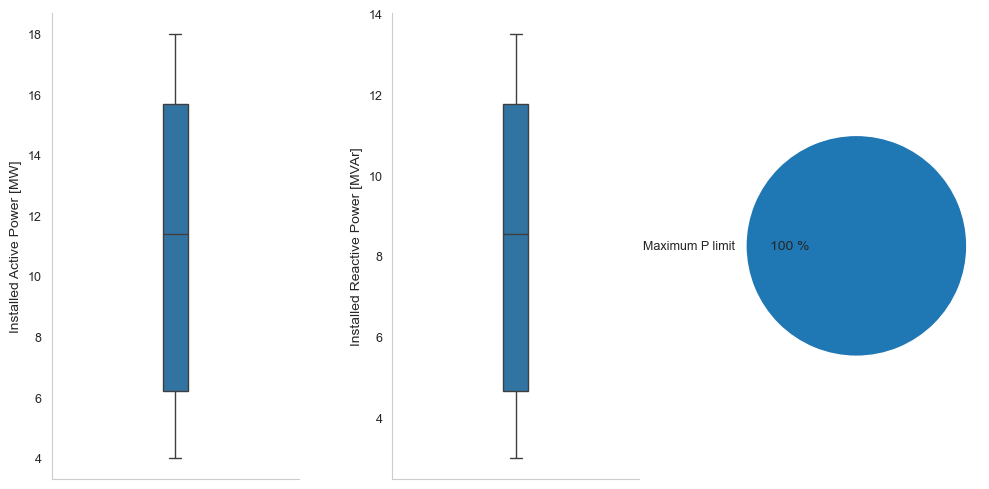

In [22]:
hc_results(load_pflag)